# Nautilus Introduction #

by some fellas

This is a tutorial for using the Nautilus sampler in `orbitize`! ([Paper here](https://google.com))

In [ ]:
import orbitize
import numpy as np

## Basic Orbit Generating

Before we get on with orbit generation, lets get some data ready. Already have a file? Lets convert it into a format the sampler can understand.

In [2]:
from orbitize.read_input import read_file
data_table = read_file('{}/GJ504.csv'.format(orbitize.DATADIR)) # path to data file, now we can input this data into the sampler

Not done yet, you have to put everyting together.

In [3]:
from orbitize import system

Now put all the data and parameters together:

In [4]:
mySys = system.System(
        1, # number of bodies in your system (int)
        data_table, # the data you got previously (table)
        1.22, # mass of the system (float)
        56.95, # paralax (float)
        0, # mass err, default is 0 (int)
        0, # plx err, default is 0 (int) 
        )

This is cool and all but if we run the sampler on this data, its going to take time. Im a tutorial we dont have time for that, instead lets generate some synthetic data with the `generate_synthetic_data()` function

Cool thing about this function is that it calculates the semi major axis for you

In [5]:
from orbitize.system import generate_synthetic_data

In [6]:
data_table, sma = generate_synthetic_data(
    95, # orbital fraction, how much of the orbit is covered (0-100%)
    1.2, # mass of the system
    60, # paralax
    0.5, # eccentricity, default is 0.5 (float)
    np.pi/4, # inclination, default is π/4 (float)
    unc=2, # uncertainty, default is 2 (int)
    num_obs=30, # number of observations to be made, default is 4 (int)
)

In [7]:
mySys = system.System(1, data_table, 1.2, 60)

Initialize the sampler

In [8]:
from orbitize import sampler

In [9]:
 mysampler = sampler.NautilusSampler(mySys)

Nice, now its time to run the sampler

In [ ]:
sampler_arg = {"n_networks": 4} # number of active networks you want, default is 4  
run_arg = {"f_live": 0.01, "n_eff": 10000} # f_live is the fraction of the evidence in the live set and n_eff is the total effective sample size
samples = mysampler.run_sampler(
        n_live=2000, # the number of live points you have, default is 2000 (int)
        num_threads=4, # the number of threads you want to utilize, default is 1 (int)
        verbose=True, # choose wether or not to see live updates of the sampler, default is false (bool)
        savefile = None, # put the name for a file that you want to create / already exists here to save nautilus progress, default is none (str)
        sampler_kwargs = sampler_arg,
        run_kwargs = run_arg
    )

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Bounding  | 17     | 2        | 8        | 100700   | 1.0000 | 1     | -418.51  

## Plotting ##

Now that we can generate possible orbits for our system, we want to plot the data to interpret our results. Here we will go through a brief overview on ways to visualize your data within orbitize. For a more detailed guide on data visualization capabilities within orbitize, see the [Orbitize plotting tutorial](https://orbitize.readthedocs.io/en/latest/tutorials/Plotting_tutorial.html).

### Histogram ###

One way to visualize our results is through histograms of our computed orbital parameters.
### One thing to keep note of: ###
Weighted posteriors

We can effectively view outputs from by creating a histogram of a given orbit element to see its distribution of possible values. Our system.param_idx dictionary is useful here. We can use it to determine the index of a given orbit that corresponds to the orbital element we are interested in:

In [23]:
mysampler.system.param_idx

{'sma1': np.int64(0),
 'ecc1': np.int64(1),
 'inc1': np.int64(2),
 'aop1': np.int64(3),
 'pan1': np.int64(4),
 'tau1': np.int64(5),
 'plx': np.int64(6),
 'mtot': np.int64(7)}

If we want to plot the distribution of orbital semi-major axes (a) in our generated orbits, we would use the index dictionary `mysampler.system.param_idx` to index the semi-major axis element from each orbit:

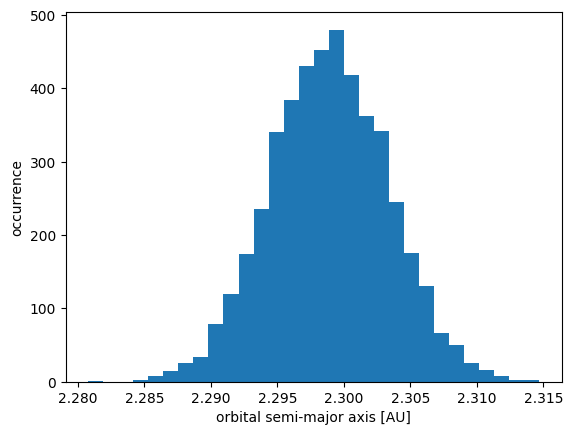

In [24]:
sma = [x[mysampler.system.param_idx['sma1']] for x in samples] 

%matplotlib inline
import matplotlib.pyplot as plt
plt.hist(sma, bins=30)
plt.xlabel('orbital semi-major axis [AU]')
plt.ylabel('occurrence')
plt.show()

You can use this method to create histograms of any orbital element you are interested in:

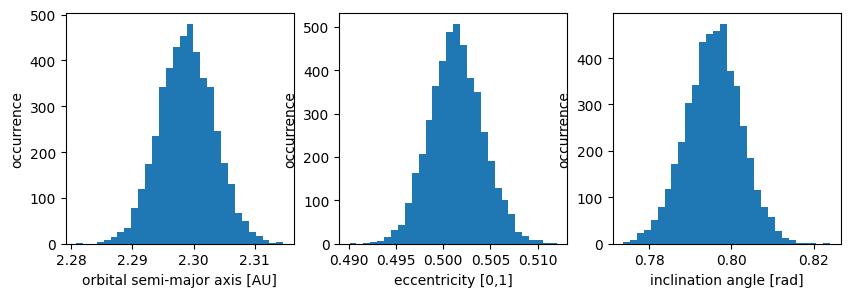

In [25]:
ecc = [x[mysampler.system.param_idx['ecc1']] for x in samples]
i = [x[mysampler.system.param_idx['inc1']] for x in samples]

plt.figure(figsize=(10,3))
plt.subplot(131)
plt.hist(sma, bins=30)
plt.xlabel('orbital semi-major axis [AU]')
plt.ylabel('occurrence')

plt.subplot(132)
plt.hist(ecc, bins=30)
plt.xlabel('eccentricity [0,1]')
plt.ylabel('occurrence')

plt.subplot(133)
plt.hist(i, bins=30)
plt.xlabel('inclination angle [rad]')
plt.ylabel('occurrence')

plt.show()

In addition to our `orbits` array, Orbitize also creates a `Results` class that contains built-in plotting capabilities for two types of plots: corner plots and orbit plots.  

### Corner Plot ###

After generating the samples, the `run_sampler` method also creates a `Results` object that can be accessed
with `s.results`:

In [26]:
myResults = mysampler.results

We can now create a corner plot using the function `plot_corner` within the `Results` class. This function requires an input list of the parameters, in string format, that you wish to include in your corner plot. We can even plot all of the orbital parameters at once! As shown below:

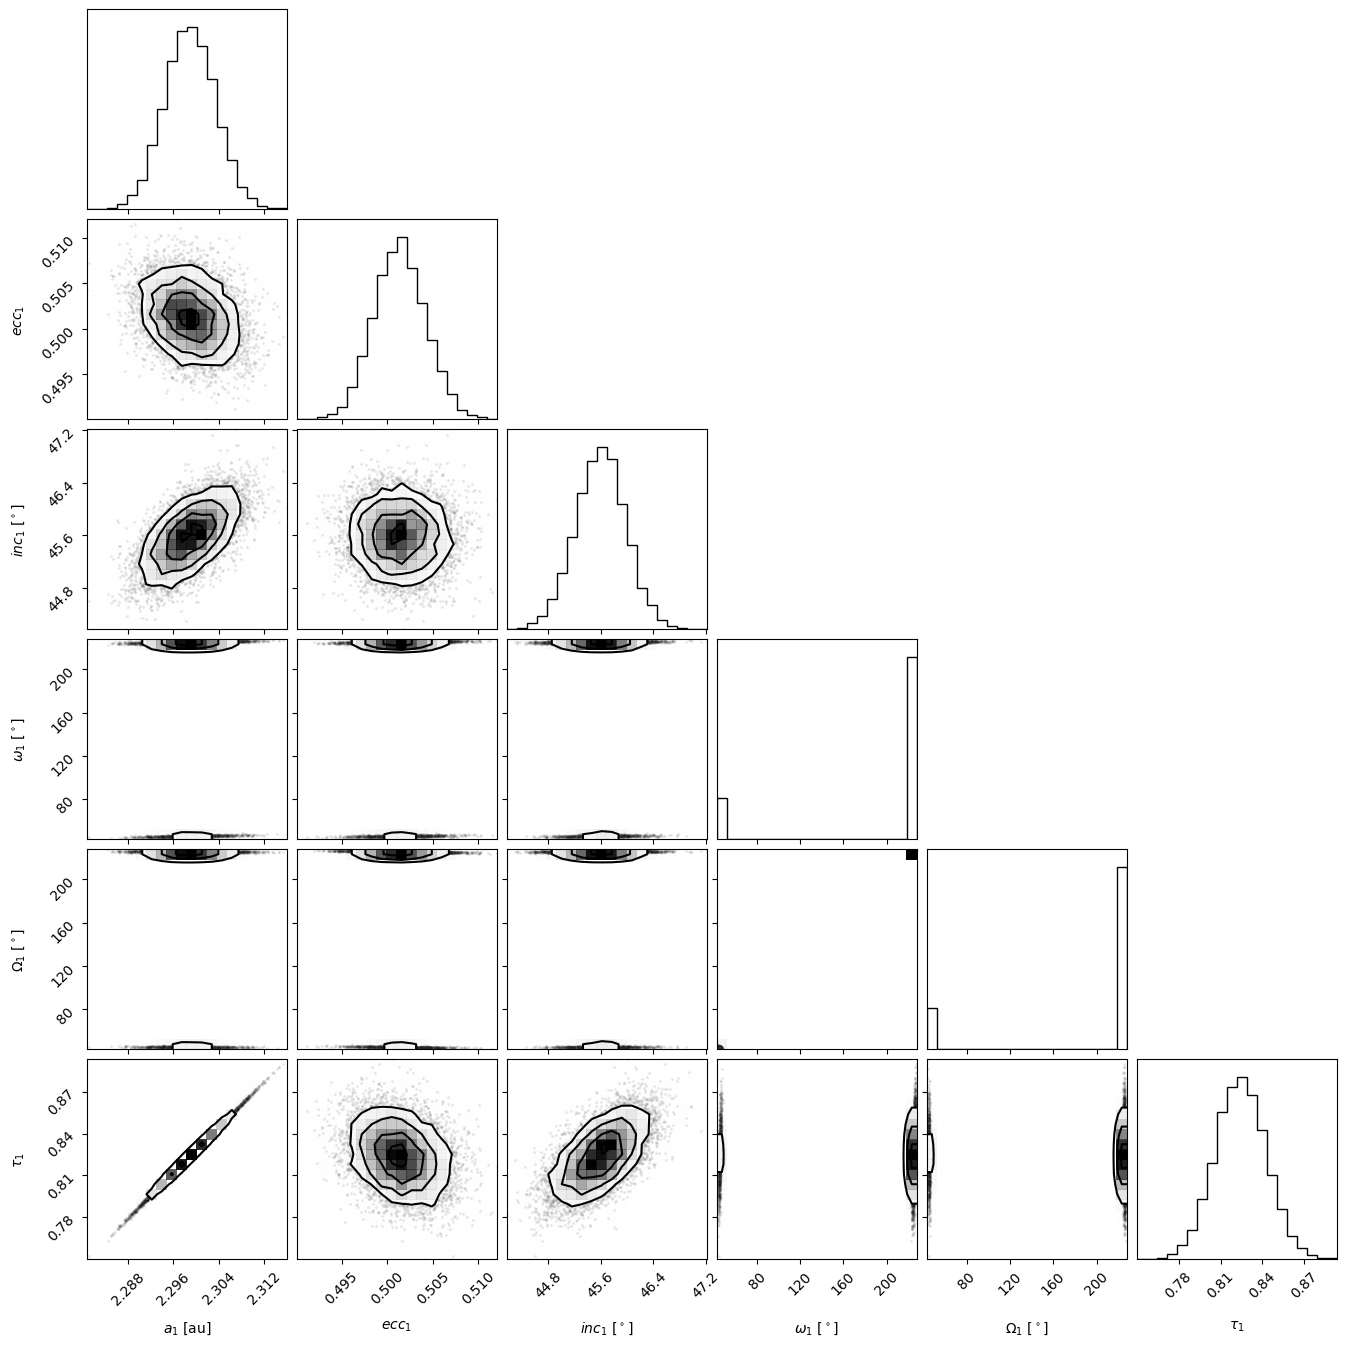

In [27]:
corner_figure = myResults.plot_corner(param_list=['sma1', 'ecc1', 'inc1', 'aop1', 'pan1','tau1'])

### A Note about Convergence

Those of you with experience looking at corner plots will note that the result here does not look converged (i.e. we need more samples for our results to be statistically significant). Because this is a tutorial, we didn't want you to have to wait around for a while for the OFTI results to converge.

Its recommended that the Nautilus sampler runs with 2000 live points for convergence. Increasing the number of live points past this does not have much of an effect on accuracy or time taken. 
Furthermore for the number of networks, 4 networks are recommended and increasing the number of networks can increase accuracy but tends to make sampling take longer amounts of time.

### Orbit Plot ###

What about if we want to see how the orbits look in the sky? Don't worry, the `Results` class has a command for that too! It's called `plot_orbits`. We can create a simple orbit plot by running the command as follows:

/home/wsl/new/new/codeastro/orbitize/orbitize/plot.py:1059: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/home/wsl/new/new/codeastro/orbitize/orbitize/plot.py:1059: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.tight_layout()


<Figure size 1400x600 with 0 Axes>

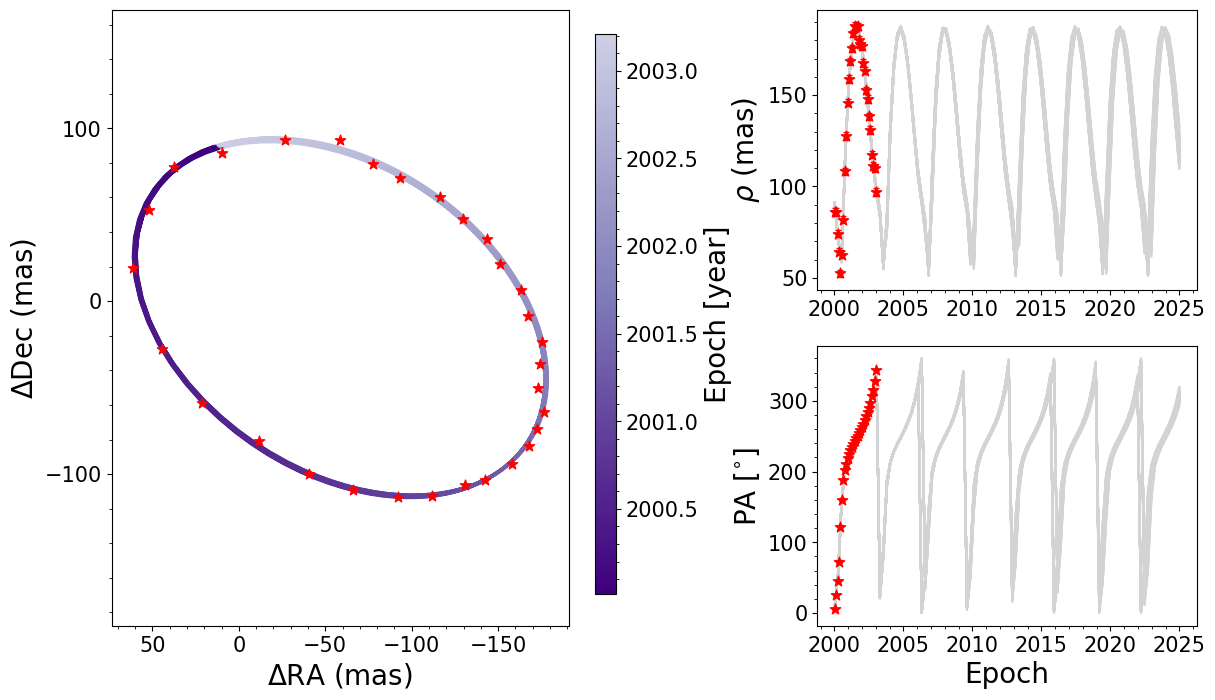

In [28]:
epochs = mySys.data_table['epoch']

orbit_figure = mysampler.results.plot_orbits(
    start_mjd=epochs[0] # Minimum MJD for colorbar (here we choose first data epoch)
)

## Saving and Loading Results ##

Finally, we can save our generated orbits in a file that can be easily read for future use and analysis. Here we will walk through the steps of saving a set of orbits to a file in hdf5 format. The easiest way to do this is using ``orbitize.Results.save_results()``:

In [19]:
mysampler.results.save_results('orbits.hdf5')

Alternatively, if you had given the option previously, you can use the file generated by nautilus that has all your orbits already saved.

Now when you are ready to use your orbits data, it is easily accessible through the file created. One way to do this is to load the data into a new `results` object; in this way you can make use of the functions that we learn before, like `plot_corner` and `plot_orbits`. To do this, use the `results` module: 

In [20]:
import orbitize.results
loaded_results = orbitize.results.Results() # create a blank results object to load the data
loaded_results.load_results('orbits.hdf5')

Alternatively, you can directly access the saved data using the `h5py` module:

In [21]:
import h5py
f = h5py.File('orbits.hdf5', 'r')
orbits = f['post']

print('orbits array dimensions: ', orbits.shape)
print('orbital elements for first orbit: ', orbits[0])

f.close()

orbits array dimensions:  (2812, 8)
orbital elements for first orbit:  [ 2.31187088  0.50436102  0.81617422  0.80350192  0.80036463  0.87742062
 60.          1.2       ]


And now we can easily work with the saved orbits that were generated by ``orbitize!`` Find out more about generating orbits in ``orbitize!`` with tutorials [here](https://orbitize.readthedocs.io/en/latest/tutorials.html).

## Nautilus API documentation ##

Nautilus Sampler

Results